In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading & Overview

In [2]:
df = pd.read_csv("zomato.csv")
print(df.shape)
df.head()

(51717, 17)


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

In [4]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [5]:
# Missing values
df.isnull().sum()


url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [6]:
# Duplicate values
df.duplicated().sum()

np.int64(0)

In [7]:
df["rate"].unique()

<StringArray>
[ '4.1/5',  '3.8/5',  '3.7/5',  '3.6/5',  '4.6/5',  '4.0/5',  '4.2/5',
  '3.9/5',  '3.1/5',  '3.0/5',  '3.2/5',  '3.3/5',  '2.8/5',  '4.4/5',
  '4.3/5',    'NEW',  '2.9/5',  '3.5/5',      nan,  '2.6/5', '3.8 /5',
  '3.4/5',  '4.5/5',  '2.5/5',  '2.7/5',  '4.7/5',  '2.4/5',  '2.2/5',
  '2.3/5', '3.4 /5',      '-', '3.6 /5',  '4.8/5', '3.9 /5', '4.2 /5',
 '4.0 /5', '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
 '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5', '4.3 /5',
 '4.4 /5',  '4.9/5',  '2.1/5',  '2.0/5',  '1.8/5', '4.6 /5', '4.9 /5',
 '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5', '2.1 /5', '2.2 /5',
 '2.0 /5', '1.8 /5']
Length: 65, dtype: str

In [8]:
df["online_order"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [9]:
df["book_table"].unique()


<StringArray>
['Yes', 'No']
Length: 2, dtype: str

## Data Cleaning

In [10]:
# remove /5 from rate column and remove the extra space  
df["rate"] = df["rate"].str.replace("/5", "", regex=False).str.strip()

In [11]:
# replace the not number value with the nan
df["rate"] = df["rate"].replace(["-", "NEW", "nan"], np.nan)

In [12]:
# convert the rate column to the numeric column by adding new column rate_numeric
df["rate_numeric"] = pd.to_numeric(df["rate"], errors="coerce")

In [13]:
# replacing comma and adding to new  column cost 
df["cost"] = df["approx_cost(for two people)"].str.replace(",", "", regex=False)

In [14]:
# changing column to numeric
df["cost"] = pd.to_numeric(df["cost"], errors="coerce")

In [15]:
# fill the mising value with median
df["rate_numeric"].fillna(df["rate_numeric"].median(), inplace=True)

/var/folders/mq/8k37xryj0_n2cz69zl90f1gm0000gn/T/ipykernel_55826/2758566814.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["rate_numeric"].fillna(df["rate_numeric"].median(), inplace=True)


0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51712    3.6
51713    3.7
51714    3.7
51715    4.3
51716    3.4
Name: rate_numeric, Length: 51717, dtype: float64

In [16]:
# converting the column data to the integer data 
df["online_order_bin"] = (df["online_order"] == "Yes").astype(int)
df["book_table_bin"]   = (df["book_table"]   == "Yes").astype(int)

##  Feature Engineering

In [17]:
# grouping the price segment 
df["price_segment"] = pd.cut(
    df["cost"],
    bins=[0, 300, 600, 1000, 10000],
    labels=["Budget", "Mid-range", "Premium", "Luxury"]
)

In [18]:
# split the value after comma
df["primary_rest_type"] = df["rest_type"].str.split(",").str[0].str.strip()

In [19]:
# Number of cuisines per restaurant
df["cuisine_count"] = df["cuisines"].str.split(",").str.len().fillna(0).astype(int)

In [20]:
# rating category according to the rating
df["rating_tier"] = pd.cut(
    df["rate_numeric"],
    bins=[0, 3.5, 4.0, 4.5, 5.0],
    labels=["Poor", "Average", "Good", "Excellent"]
)

In [21]:
df[["price_segment","cuisine_count","primary_rest_type","rating_tier"]].head()

,price_segment,cuisine_count,primary_rest_type,rating_tier
0,Premium,3,Casual Dining,Good
1,Premium,3,Casual Dining,Good
2,Premium,3,Cafe,Average
3,Budget,2,Quick Bites,Average
4,Mid-range,2,Casual Dining,Average


##  Exploratory Visualisations

### Rating Distribution

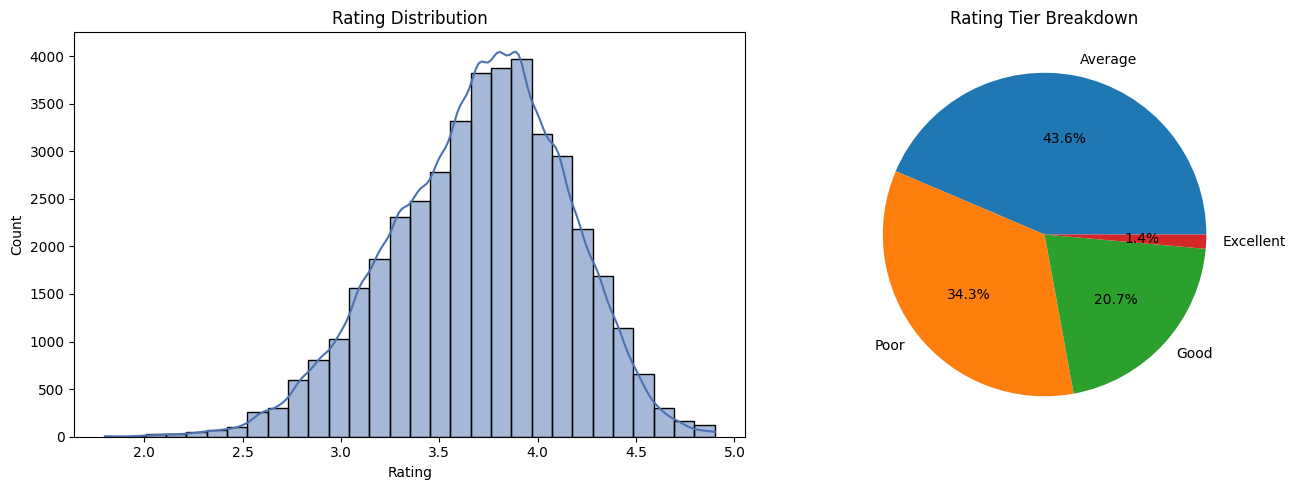

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["rate_numeric"], bins=30, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Rating")

df["rating_tier"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[1])
axes[1].set_title("Rating Tier Breakdown")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


### 4.2 Online Order & Table Booking

/var/folders/mq/8k37xryj0_n2cz69zl90f1gm0000gn/T/ipykernel_55826/4168392802.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="online_order", order=["Yes","No"], palette=["#55a868","#c44e52"], ax=axes[0])
/var/folders/mq/8k37xryj0_n2cz69zl90f1gm0000gn/T/ipykernel_55826/4168392802.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="book_table", order=["Yes","No"], palette=["#55a868","#c44e52"], ax=axes[1])
/var/folders/mq/8k37xryj0_n2cz69zl90f1gm0000gn/T/ipykernel_55826/4168392802.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effe

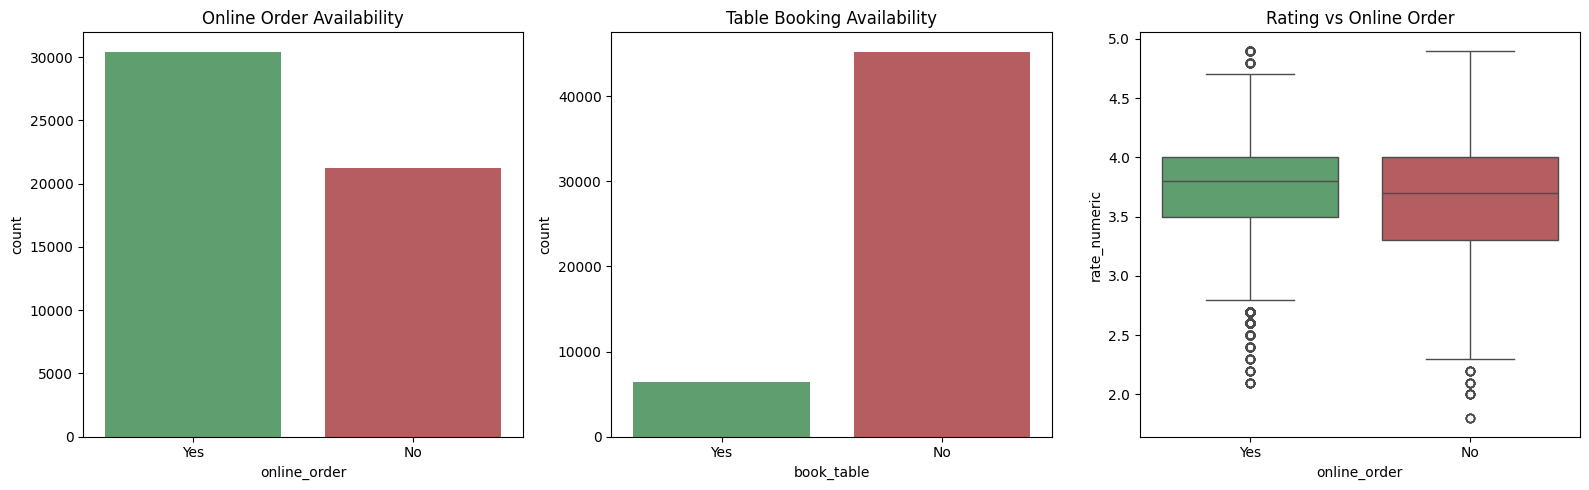

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(data=df, x="online_order", order=["Yes","No"], palette=["#55a868","#c44e52"], ax=axes[0])
axes[0].set_title("Online Order Availability")

sns.countplot(data=df, x="book_table", order=["Yes","No"], palette=["#55a868","#c44e52"], ax=axes[1])
axes[1].set_title("Table Booking Availability")

sns.boxplot(data=df, x="online_order", y="rate_numeric", order=["Yes","No"],
            palette=["#55a868","#c44e52"], ax=axes[2])
axes[2].set_title("Rating vs Online Order")

plt.tight_layout()
plt.show()


### 4.3 Top Locations

/var/folders/mq/8k37xryj0_n2cz69zl90f1gm0000gn/T/ipykernel_55826/730591476.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_loc.index, x=top_loc.values, palette="Blues_d", ax=axes[0])


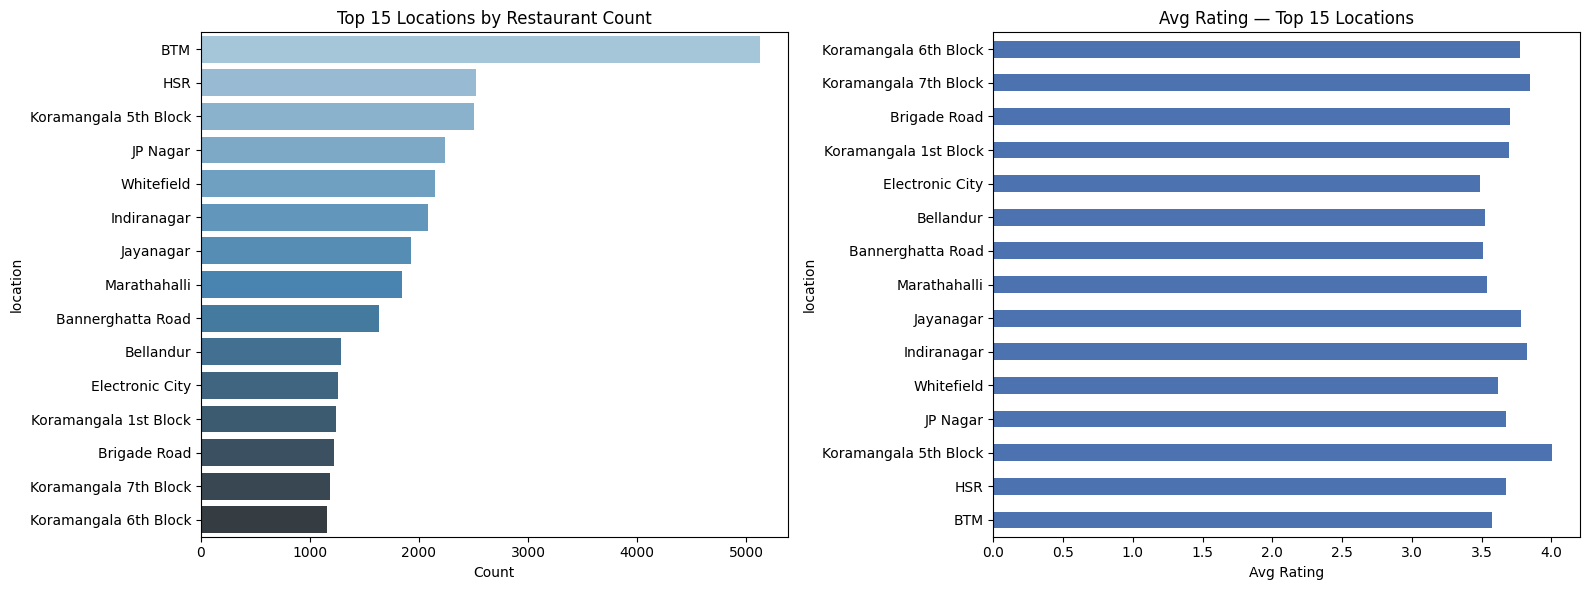

In [24]:
top_loc = df["location"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(y=top_loc.index, x=top_loc.values, palette="Blues_d", ax=axes[0])
axes[0].set_title("Top 15 Locations by Restaurant Count")
axes[0].set_xlabel("Count")

avg_rating_loc = df[df["location"].isin(top_loc.index)].groupby("location")["rate_numeric"].mean().reindex(top_loc.index)
avg_rating_loc.plot.barh(ax=axes[1], color="#4C72B0")
axes[1].set_title("Avg Rating — Top 15 Locations")
axes[1].set_xlabel("Avg Rating")

plt.tight_layout()
plt.show()


### 4.4 Top Cuisines

/var/folders/mq/8k37xryj0_n2cz69zl90f1gm0000gn/T/ipykernel_55826/2386787817.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_cuisines.index, x=top_cuisines.values, palette="tab20")


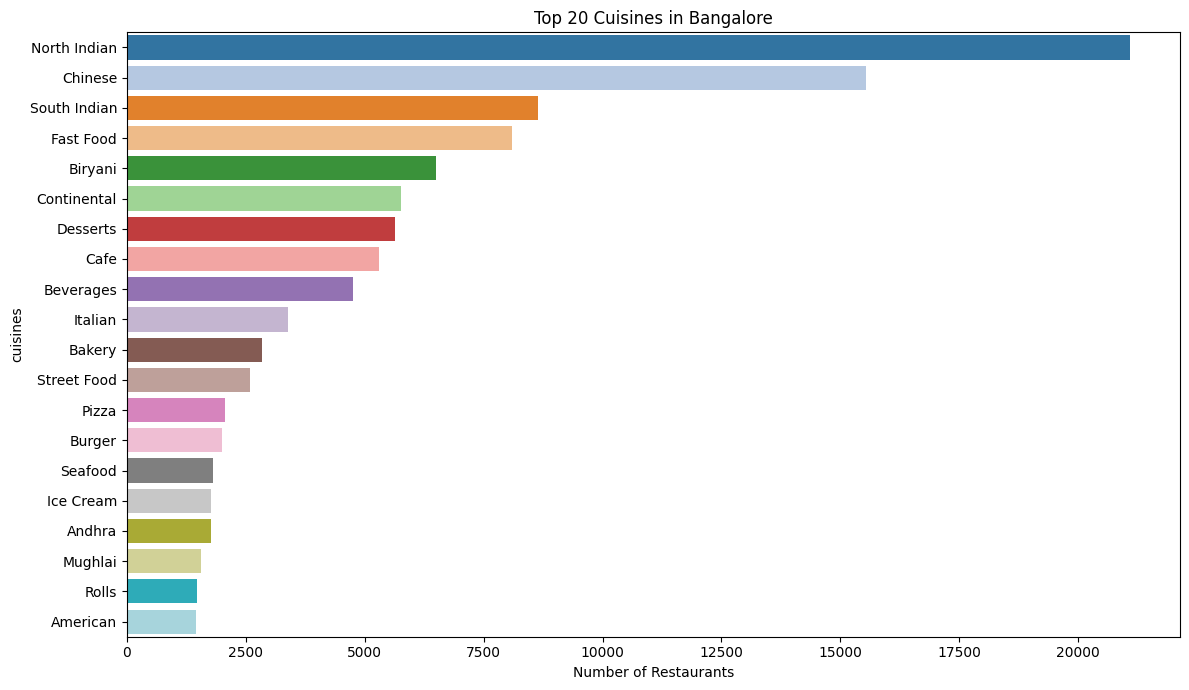

In [25]:
top_cuisines = df["cuisines"].str.split(",").explode().str.strip().value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(y=top_cuisines.index, x=top_cuisines.values, palette="tab20")
plt.title("Top 20 Cuisines in Bangalore")
plt.xlabel("Number of Restaurants")
plt.tight_layout()
plt.show()


### 4.5 Cost Distribution & Price Segments

/var/folders/mq/8k37xryj0_n2cz69zl90f1gm0000gn/T/ipykernel_55826/1925843772.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


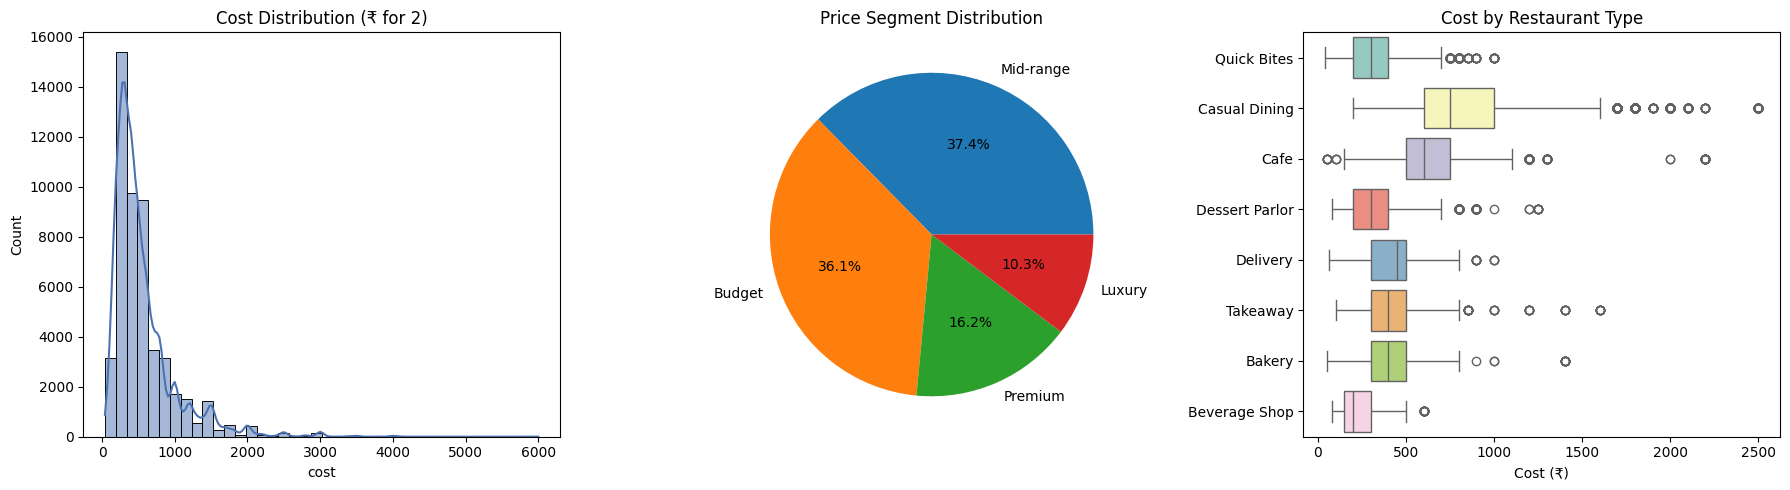

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["cost"].dropna(), bins=40, kde=True, color="#4C72B0", ax=axes[0])
axes[0].set_title("Cost Distribution (₹ for 2)")

df["price_segment"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[1])
axes[1].set_title("Price Segment Distribution")
axes[1].set_ylabel("")

top8_types = df["primary_rest_type"].value_counts().head(8).index
sns.boxplot(
    data=df[df["primary_rest_type"].isin(top8_types)],
    y="primary_rest_type", x="cost",
    order=top8_types, palette="Set3", ax=axes[2]
)
axes[2].set_title("Cost by Restaurant Type")
axes[2].set_xlabel("Cost (₹)")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


### 4.6 Votes vs Rating

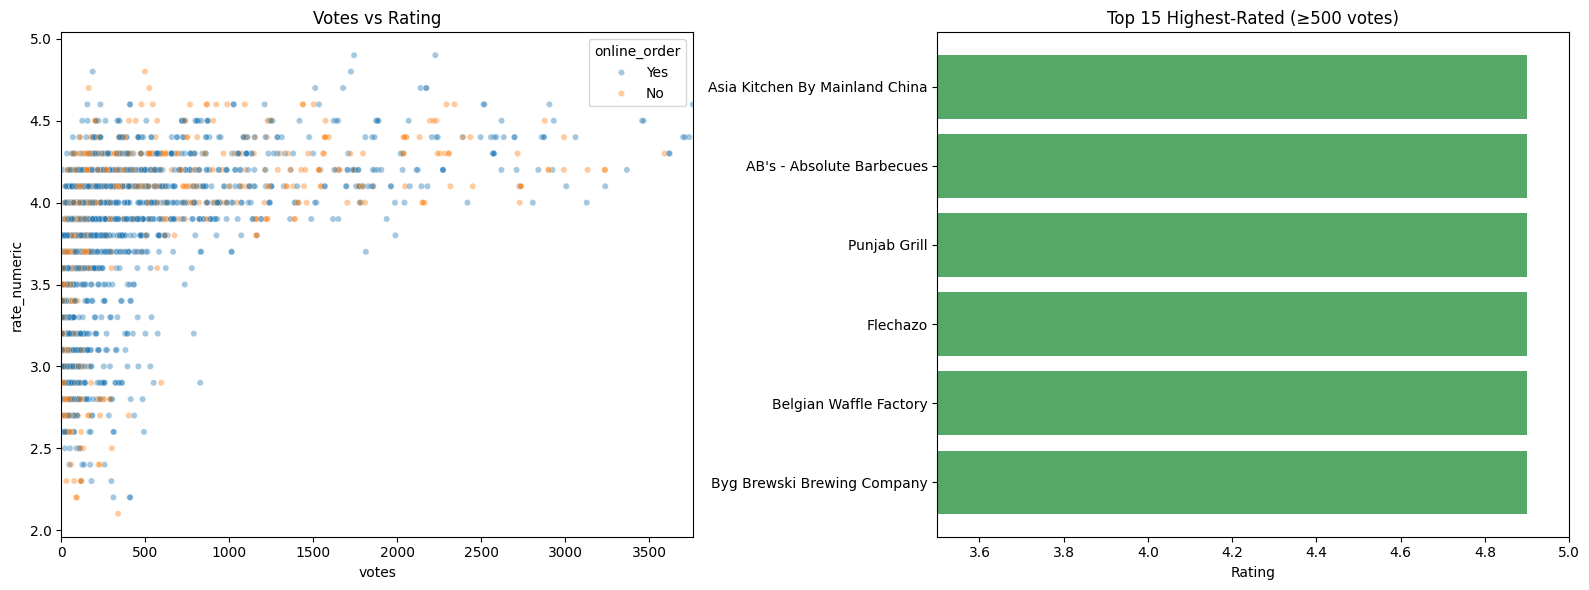

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample = df.sample(5000, random_state=42)
sns.scatterplot(data=sample, x="votes", y="rate_numeric", hue="online_order",
                alpha=0.4, s=20, ax=axes[0])
axes[0].set_title("Votes vs Rating")
axes[0].set_xlim(0, sample["votes"].quantile(0.99))

top_rated = df[df["votes"] >= 500].nlargest(15, "rate_numeric").drop_duplicates("name")
axes[1].barh(top_rated["name"].str[:30], top_rated["rate_numeric"], color="#55a868")
axes[1].set_title("Top 15 Highest-Rated (≥500 votes)")
axes[1].set_xlabel("Rating")
axes[1].set_xlim(3.5, 5)

plt.tight_layout()
plt.show()


### 4.7 Restaurant Type Analysis

/var/folders/mq/8k37xryj0_n2cz69zl90f1gm0000gn/T/ipykernel_55826/1820510202.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top8_types.index, x=top8_types.values, palette="husl", ax=axes[0])


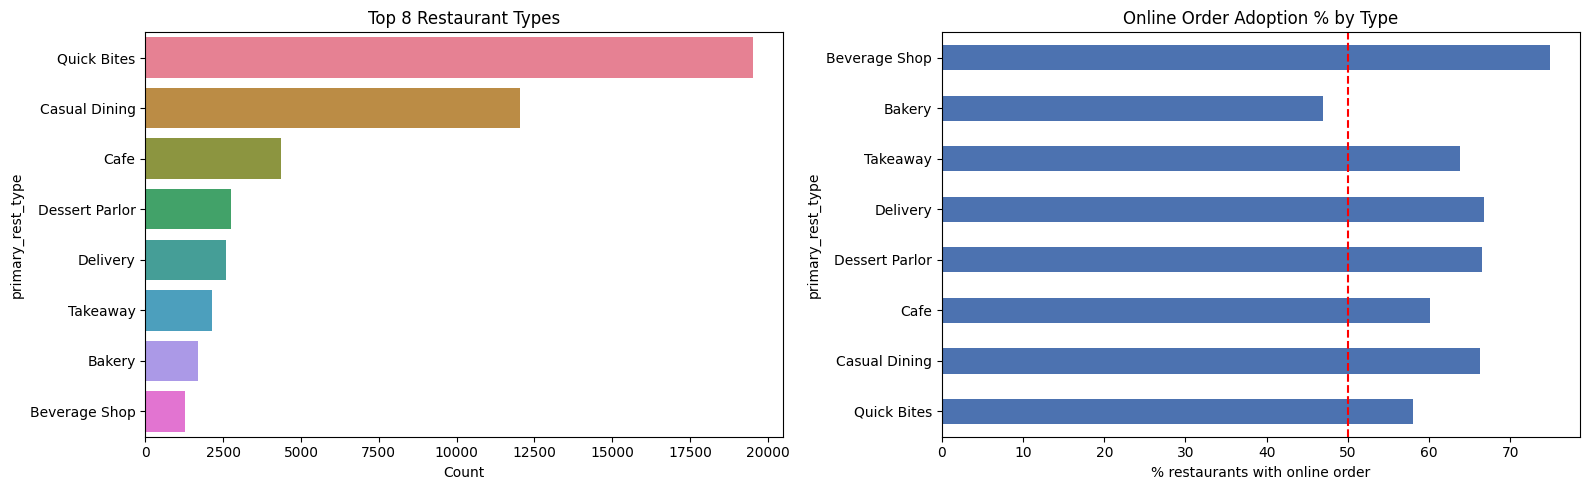

In [28]:
top8_types = df["primary_rest_type"].value_counts().head(8)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(y=top8_types.index, x=top8_types.values, palette="husl", ax=axes[0])
axes[0].set_title("Top 8 Restaurant Types")
axes[0].set_xlabel("Count")

online_rate = df[df["primary_rest_type"].isin(top8_types.index)].groupby("primary_rest_type")["online_order_bin"].mean().mul(100).reindex(top8_types.index)
online_rate.plot.barh(ax=axes[1], color="#4C72B0")
axes[1].axvline(50, color="red", ls="--")
axes[1].set_title("Online Order Adoption % by Type")
axes[1].set_xlabel("% restaurants with online order")

plt.tight_layout()
plt.show()


### 4.8 Correlation Heatmap

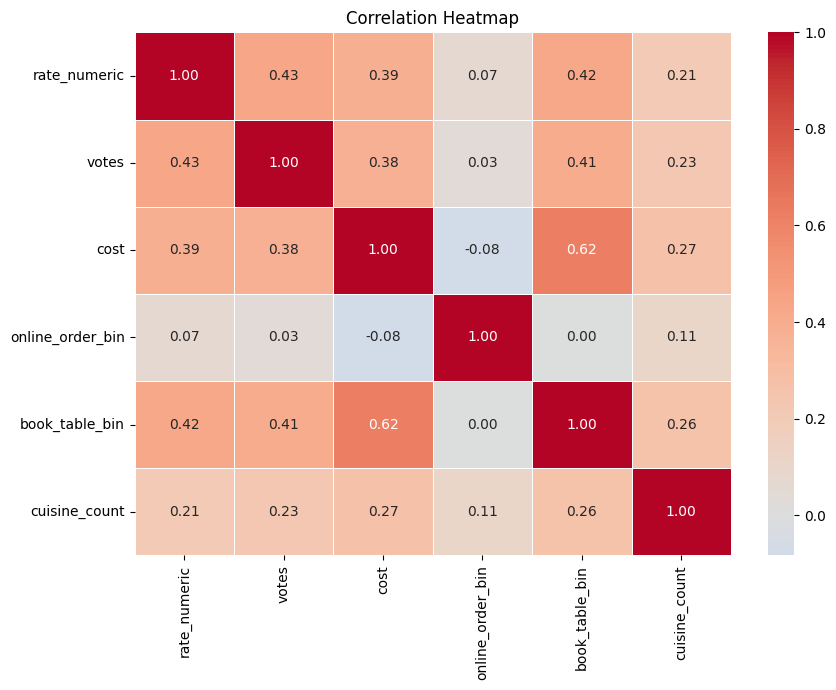

In [29]:
num_cols = ["rate_numeric", "votes", "cost", "online_order_bin", "book_table_bin", "cuisine_count"]
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### 4.9 Rating by Price Segment

/var/folders/mq/8k37xryj0_n2cz69zl90f1gm0000gn/T/ipykernel_55826/1311374049.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="price_segment", y="rate_numeric",


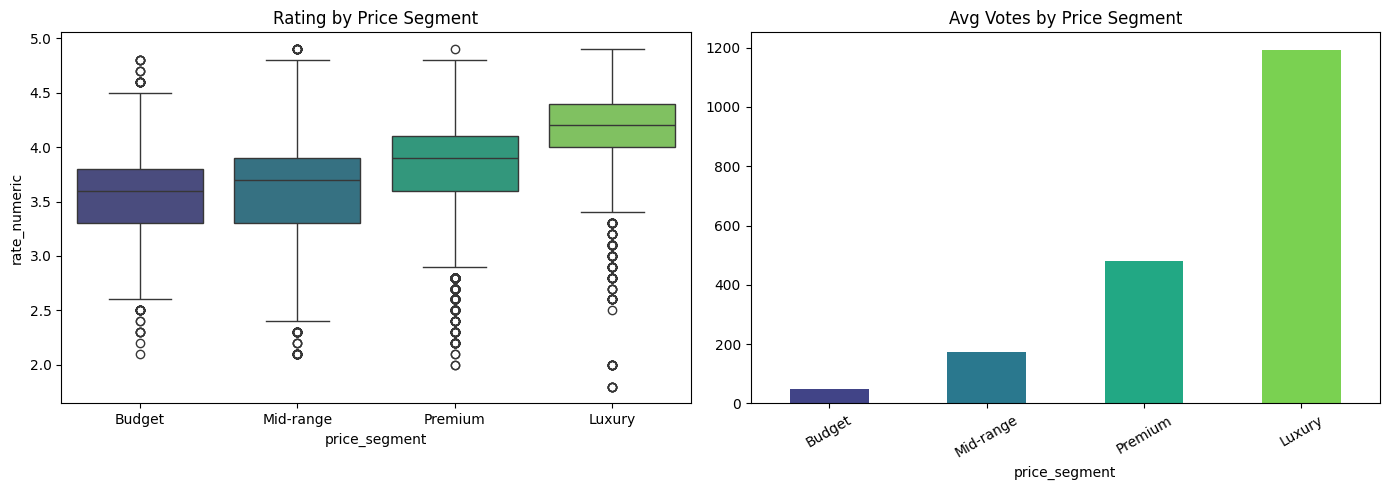

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="price_segment", y="rate_numeric",
            order=["Budget","Mid-range","Premium","Luxury"], palette="viridis", ax=axes[0])
axes[0].set_title("Rating by Price Segment")

df.groupby("price_segment")["votes"].mean().reindex(["Budget","Mid-range","Premium","Luxury"]).plot.bar(
    ax=axes[1], color=sns.color_palette("viridis", 4)
)
axes[1].set_title("Avg Votes by Price Segment")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


### 4.10 Cuisine Count vs Rating

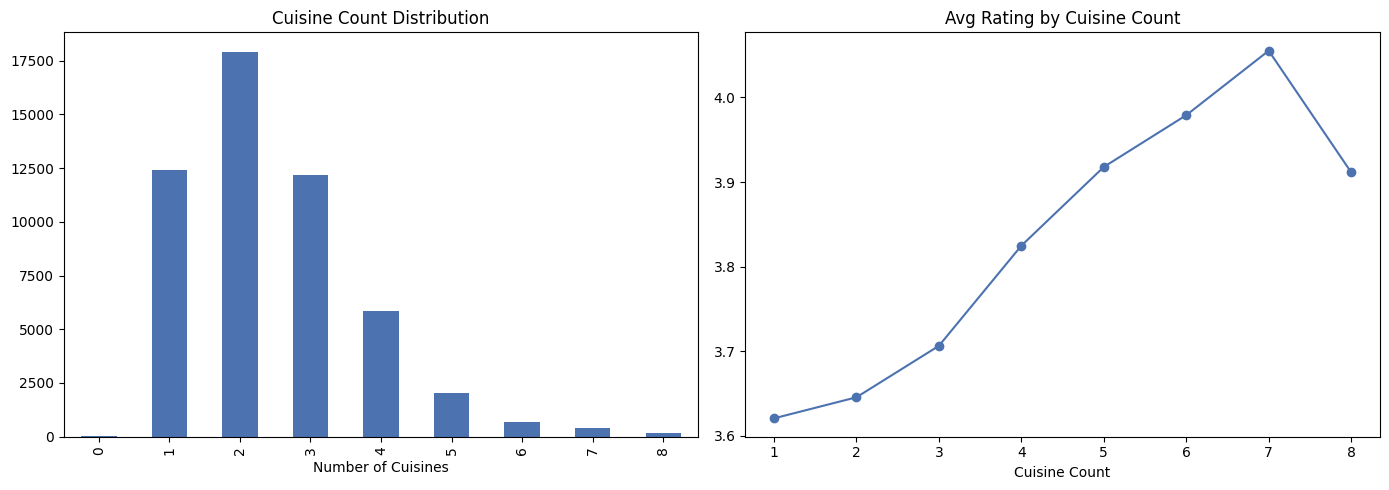

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df["cuisine_count"] <= 8]["cuisine_count"].value_counts().sort_index().plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Cuisine Count Distribution")
axes[0].set_xlabel("Number of Cuisines")

df[df["cuisine_count"].between(1,8)].groupby("cuisine_count")["rate_numeric"].mean().plot(
    marker="o", ax=axes[1], color="#4C72B0"
)
axes[1].set_title("Avg Rating by Cuisine Count")
axes[1].set_xlabel("Cuisine Count")

plt.tight_layout()
plt.show()


## 5. Business Insights

| # | Insight | Action |
|---|---------|--------|
| 1 | Restaurants with **online ordering** rate ~0.2–0.3 pts higher | Enable online ordering immediately |
| 2 | **Table booking** adopted by only ~20% | Easy differentiation — add it now |
| 3 | **BTM, Koramangala, HSR** are over-saturated | Target Whitefield, Hebbal for new openings |
| 4 | **North Indian, Chinese, South Indian** dominate cuisines | Niche cuisines face less competition |
| 5 | Most restaurants are **Mid-range ₹300–600** | Budget & Luxury are under-served segments |
| 6 | **Luxury restaurants** get far more votes on average | High-ticket dining drives word-of-mouth |
| 7 | Restaurants with **1–3 cuisines** have the best ratings | Focus / specialise your menu |
| 8 | **Votes and rating** have moderate positive correlation | Marketing drives visibility AND quality signals |


## 6. Cleaned Dataset Summary

In [32]:
print("Total restaurants:         ", len(df))
print("Unique locations:          ", df["location"].nunique())
print("Avg rating:                ", round(df["rate_numeric"].mean(), 2))
print("Median cost for 2:        ₹", df["cost"].median())
print("Online ordering %:         ", round(df["online_order_bin"].mean()*100, 1))
print("Table booking %:           ", round(df["book_table_bin"].mean()*100, 1))
print()
print("Price Segment Counts:")
print(df["price_segment"].value_counts())
print()
print("Rating Tier Counts:")
print(df["rating_tier"].value_counts())


Total restaurants:          51717
Unique locations:           93
Avg rating:                 3.7
Median cost for 2:        ₹ 400.0
Online ordering %:          58.9
Table booking %:            12.5

Price Segment Counts:
price_segment
Mid-range    19205
Budget       18554
Premium       8332
Luxury        5280
Name: count, dtype: int64

Rating Tier Counts:
rating_tier
Average      18165
Poor         14284
Good          8628
Excellent      588
Name: count, dtype: int64


In [34]:
df.to_csv("cleaned_data.csv", index=False)